# Simple Scheduling Algorithm using QAOA



N tasks    \
M workers  \
M <= N     

Assign tasks to workers    \
Each task assigned only to one worker

input  - Weight matrix, W \
output - optimized scheuling of tasks to workers resulting a least cost \
                      \
W(i, j) indicate the cost of jth task assigned to ith worker



### QAOA procedure for Simple Scheduling

1. Weight matrix to QUBO Cost

2. QUBO Cost to Hamiltonian

3. QAOA Circuit
    * QAOA Ansatz
    * Transpile to Aer Simulator circuit

4. Optimization
    * Estimator for evaluating Energy or Cost
    * Classical parameter optimization through minimize function

5. Results
    * Generate Sampler output of the circuit assigned with best parameters
    * Optimal Scheduling
    * Visualization



In [1]:
import sys
print("Python executable:", sys.executable)
print("Python version:", sys.version)

Python executable: c:\Users\kcrav\miniconda3\envs\myenv\python.exe
Python version: 3.11.14 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 18:30:03) [MSC v.1929 64 bit (AMD64)]


In [2]:
#!jupyter kernelspec list

In [3]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# Qiskit libraries
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram, plot_state_city
import qiskit.quantum_info as qi

from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler

from scipy.optimize import minimize

## Weight matrix to Classical QUBO Cost




In [4]:
N = 4
M = 2
K = int(np.ceil(np.log2(N)))
p_reps = 2

def inititialize_parameters(p_reps):

    init_param_values = []

    if p_reps == 4:
        init_param_values = [np.pi / 3, np.pi / 4, np.pi / 3, np.pi/4.5, np.pi/3.5, np.pi / 6, np.pi/4.8, np.pi / 5]
    elif p_reps == 3:
        init_param_values = [np.pi / 3, np.pi / 4, np.pi / 3, np.pi/4.5, np.pi/3.5, np.pi / 5]
    elif p_reps == 2:
        init_param_values = [np.pi / 3, np.pi / 4, np.pi / 5, np.pi/4.5]
    elif p_reps == 1:
        init_param_values = [np.pi / 3, np.pi / 6]
        
    return init_param_values

init_param_values = inititialize_parameters(p_reps)

assert N > 0 and M > 0, "N and M must be positive integers."
#assert N >= M, "N must be greater than or equal to M for a valid scheduling problem."

def generate_weight_matrix(M, N):
    w = np.random.randint(1, 1000, size=(M, N))
    return w

w = generate_weight_matrix(M, N)
print('w:', w)

w_col = w.reshape(-1, 1)
print(w_col)


w: [[930 297 217 542]
 [781 586 580 377]]
[[930]
 [297]
 [217]
 [542]
 [781]
 [586]
 [580]
 [377]]


### brute_force_min_max_wx

In [5]:
def brute_force_min_max_wx(w, M, N):
    Time_brute_force_min_max_wx = 100000000
    x_brute_force_min_max_wx = None
    for i in range(2**(M*N)):
        x = np.array(list(np.binary_repr(i, width=M*N)), dtype=int)
        
        reshaped_x = np.array(x).reshape(M,N)        

        if np.sum(reshaped_x) != N:
            continue        

        bool_skip_maxTime = 0
        for l in range(N):
            if np.sum(reshaped_x[:,l])!=1:
                bool_skip_maxTime = 1
                break

        if bool_skip_maxTime:
            continue

        alloted_times = reshaped_x * w
        max_time = 0
        for j in range(M):
            max_time = max(max_time, np.sum(alloted_times[j,:]))
        if Time_brute_force_min_max_wx > max_time:
            Time_brute_force_min_max_wx = max_time
            x_brute_force_min_max_wx = reshaped_x
        #print(max_time)

    return Time_brute_force_min_max_wx, x_brute_force_min_max_wx

if M*N <= 20:
    Time_brute_force_min_max_wx, x_brute_force_min_max_wx = brute_force_min_max_wx(w, M, N)
    
    print('w \n', w)    
    print('x_brute_force_min_max_wx \n', x_brute_force_min_max_wx)
    print('Time_brute_force_min_max_wx: ', Time_brute_force_min_max_wx)


w 
 [[930 297 217 542]
 [781 586 580 377]]
x_brute_force_min_max_wx 
 [[0 1 1 1]
 [1 0 0 0]]
Time_brute_force_min_max_wx:  1056


### QUBO_Q_C

In [6]:
def QUBO_Q_C(w, a,b,c):

    Q = np.zeros((M * N + M*K + K, M * N + M*K + K))  # initialize Q as a lower triangular matrix of ones

    A_ = 10
    B_ = 100
    C_ = 1

    A_ = a
    B_ = b
    C_ = c



    const_0_1 = 1

    w = w/np.sum(w.reshape(1,-1))

    for i in range(M):
        for j in range(N):
            for l in range(j):
                Q[i * N + j, i * N + l] = (1+const_0_1)*A_*w[i,j]*w[i,l]
                Q[i * N + l, i * N + j] = (1-const_0_1)*A_*w[i,l]*w[i,j]
    row_offset = M*N
    col_offset = M*N
    for i in range(M):
        for j in range(K):
            for l in range(j):
                Q[row_offset + i * K + j, col_offset + i * K + l] = (1+const_0_1)*A_*2**(j+l)
                Q[row_offset + i * K + l, col_offset + i * K + j] = (1-const_0_1)*A_*2**(j+l)
    row_offset = M*N+M*K
    col_offset = M*N+M*K
    for i in range(1):
        for j in range(K):
            for l in range(j):
                Q[row_offset + i * K + j, col_offset + i * K + l] = (1+const_0_1)*A_*2**(j+l)
                Q[row_offset + i * K + l, col_offset + i * K + j] = (1+const_0_1)*A_*2**(j+l)
    row_offset = M*N
    col_offset = 0
    for i in range(M):
        for j in range(K):
            for l in range(N):
                Q[row_offset + i * K + j, col_offset + i * N + l] = (1+const_0_1)*A_*(2**j)*w[i,l]
                Q[col_offset + i * N + l, row_offset + i * K + j] = (1-const_0_1)*A_*(2**j)*w[i,l]
    row_offset = M*N+M*K
    col_offset = 0
    for i in range(M):
        for j in range(K):
            for l in range(N):
                Q[row_offset + j, col_offset + i * N + l] = -(1+const_0_1)*A_*(2**j)*w[i,l]
                Q[col_offset + i * N + l, row_offset + j] = -(1-const_0_1)*A_*(2**j)*w[i,l]
    row_offset = M*N+M*K
    col_offset = M*N
    for i in range(M):
        for j in range(K):
            for l in range(K):
                Q[row_offset + j, col_offset + i * K + l] = -(1+const_0_1)*A_*2**(j+l)
                Q[col_offset + i * K + l, row_offset + j] = -(1-const_0_1)*A_*2**(j+l)

    for j in range(N):
        for i in range(M):
            for n in range(i):
                Q[i * N + j, n * N + j] += (1+const_0_1)*B_
                Q[n * N + j, i * N + j] += (1-const_0_1)*B_

    M1 = np.zeros(M*N)
    M2 = np.zeros(M*K)
    M3 = np.zeros(K)
    for i in range(M):
        for j in range(N):
            M1[i*N + j] = A_*w[i,j]*w[i,j] + B_ - 2*B_
    for i in range(M):
        for j in range(K):
            M2[i*K + j] = A_*(2**(2*i))
    for i in range(K):
            M3[i] = A_*2**(2*i) + C_*(2**i)

    C = np.concatenate((M1, M2, M3), axis=0)

    #print(M*N, M*K, K, len(C), M*N+M*K+K)

    #C = w_col/(np.sum(w_col)) - 1/(N)*np.ones((M * N, 1))
    #C = w_col*(.5/(2*L)) - .5*np.ones((M * N, 1))
    #C = .1*w_col - L*np.ones((M * N, 1))

    #print(np.diag(Q))
    #print(np.diag(np.diag(Q)))
    #Q = Q - np.diag(np.diag(Q))  # set diagonal elements to zero


    #print('Q:', Q)
    #print('C:', C)

    return Q, C


### brute_force_QUBO_classical

In [7]:
def qubo_cost_function(x, Q, C):
    return 0.5 * x.T @ Q @ x + C.T @ x

Q, C = QUBO_Q_C(w, 1,10,1)


# brute-force search for CLASSICAL QUBO
def brute_force_QUBO_classical(Q, C, w, M, N, K):
    min_cost = 100000
    x_brute_force_QUBO_classical = None
    for i in range(2**(M*N+M*K+K)):
        x = np.array(list(np.binary_repr(i, width=M*N+M*K+K)), dtype=int)
        cost = qubo_cost_function(x, Q, C)
        if cost < min_cost:
            min_cost = cost
            x_brute_force_QUBO_classical = x

    reshaped_x = x_brute_force_QUBO_classical[:M*N].reshape(M,N)
    alloted_times = reshaped_x * w
    max_time = 0
    for j in range(M):
        max_time = max(max_time, np.sum(alloted_times[j,:]))
    Time_brute_force_QUBO_classical = max_time
    x_brute_force_QUBO_classical = reshaped_x

    return Time_brute_force_QUBO_classical, x_brute_force_QUBO_classical

if M*N+M*K+K <= 20:

    Time_brute_force_QUBO_classical, x_brute_force_QUBO_classical = brute_force_QUBO_classical(Q, C, w, M, N, K)

    print('x_brute_force_QUBO_classical \n', x_brute_force_QUBO_classical)
    print('Time_brute_force_QUBO_classical', Time_brute_force_QUBO_classical)



x_brute_force_QUBO_classical 
 [[0 1 1 0]
 [1 0 0 1]]
Time_brute_force_QUBO_classical 1158


## Classical QUBO to Hamiltonian




In [8]:
def classical_qubo_to_hamiltonian(Q, C):
    n = len(C)
    pauli_list = []
    
    for i in range(n):
        if C[i] != 0 or np.sum(Q[i,:]) != 0:
            pauli_list.append(('Z', [i], -np.float64(np.sum(Q[i,:])/4 + np.sum(Q[:,i])/4 + C[i]/2)))
            #pauli_list.append(('Z', [i], -np.float64(np.sum(Q[i,:])/2 + C[i][0]/2)))
            pass
    
    for i in range(n):
        for j in range(i):
            if Q[i, j] != 0:
                pauli_list.append(('ZZ', [i, j], np.float64(Q[i, j]/4)))
                pauli_list.append(('ZZ', [j, i], np.float64(Q[j, i]/4)))
                pass
    
    return pauli_list

In [ ]:
pauli_list = classical_qubo_to_hamiltonian(Q, C)
no_of_qubits = M*N + M*K + K
Cost_hamiltonian = SparsePauliOp.from_sparse_list(pauli_list, num_qubits=no_of_qubits)
Cost_hamiltonian


## QAOA Circuit

### QAOA Ansatz


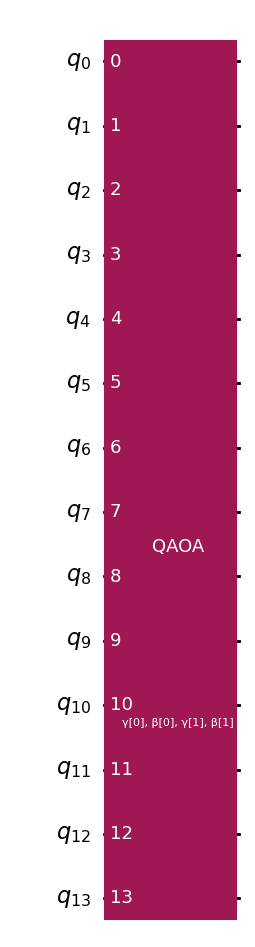

In [10]:
circuit = QAOAAnsatz(cost_operator=Cost_hamiltonian, reps=p_reps)
#circuit.measure_all()

circuit.draw("mpl")

In [11]:
#circuit.decompose().draw("mpl")


### Transpile to Aer Simulator circuit


In [12]:
circuit.parameters

ParameterView([ParameterVectorElement(β[0]), ParameterVectorElement(β[1]), ParameterVectorElement(γ[0]), ParameterVectorElement(γ[1])])

In [13]:
binding_dict = {param: value for param, value in zip(circuit.parameters, init_param_values)}
bound_circuit = circuit.assign_parameters(binding_dict)
bound_circuit.parameters

ParameterView([])

In [14]:
simulator = AerSimulator(method="statevector")
Aer_transpiled_ckt = transpile(circuit, simulator)

Aer_transpiled_ckt.save_statevector()

#Aer_transpiled_ckt.draw("mpl")

### State vector simulation (checking for initial parameters)

In [15]:
bound_Aer_transpiled_ckt = Aer_transpiled_ckt.assign_parameters(binding_dict)

results = simulator.run(bound_Aer_transpiled_ckt).result()
counts = results.get_counts()
#plot_histogram(counts, title="State Vector without measurement")

In [16]:
state_vector = results.get_statevector()

#plot_state_city(state_vector, title="State Vector City Plot")

## Optimization

### Estimator for evaluating Energy or Cost



In [17]:
obj_fn_costs_iter = []
parameter_values_iter = []

In [18]:
def Average_Energy(parameter_values, transpiled_circuit, Cost_hamiltonian, estimator):
    # Bind the parameters to the circuit
    binding_dict = {param: value for param, value in zip(transpiled_circuit.parameters, parameter_values)}

    isa_hamiltonian = Cost_hamiltonian.apply_layout(transpiled_circuit.layout)

    pub = (transpiled_circuit, isa_hamiltonian, parameter_values)

    results = estimator.run([pub]).result()

    obj_fn_costs_iter.append(results[0].data.evs)
    parameter_values_iter.append(list(parameter_values))

    return results[0].data.evs # energy

### Parameter optimization through minimize function

Hybrid Quantum-Classical workflow
- Parameter optimization - Classical processing
- Energy calculation - QPU/Simulator


Optimal parameters: [ 1.05535551 -0.13697808  2.0369802   0.33127022]
Minimum energy: -12.608854150314926


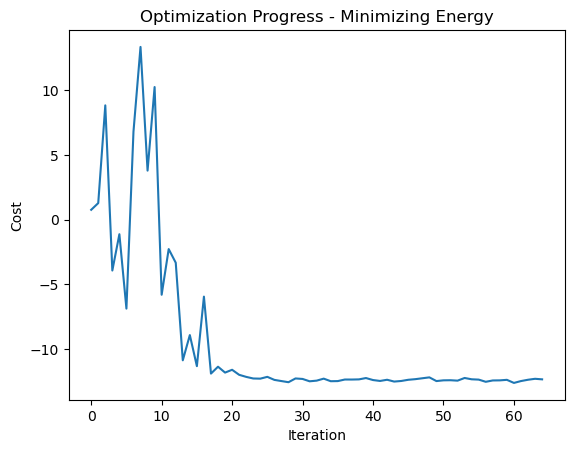

In [19]:
obj_fn_costs_iter = []
parameter_values_iter = []

simulator = AerSimulator(method="statevector")
Aer_transpiled_ckt = transpile(circuit, simulator)

estimator = Estimator(mode=simulator)
estimator.options.default_shots = 1024*16

param_values_init = [0.77254496, 1.24810316] # [553/L, 1.2481] # [10/L, 10/L]
param_values_init = [2.30713335, 0.9512575 ] # [.002, .01] # [553/L, 1.2481] # [10/L, 10/L]
param_values_init = init_param_values

result = minimize(
        Average_Energy,
        param_values_init,
        args=(Aer_transpiled_ckt, Cost_hamiltonian, estimator),
        method="COBYLA",
        tol=1e-6,
        #options={'rhobeg': .0001},
)

optimal_parameters = result.x
optimal_energy = result.fun

print("Optimal parameters:", result.x)
print("Minimum energy:", result.fun)

plt.plot(obj_fn_costs_iter)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Optimization Progress - Minimizing Energy")
plt.show()

## Results


### Generate Sampler output of the circuit assigned with best parameters


In [ ]:
bound_Aer_transpiled_ckt = Aer_transpiled_ckt.assign_parameters(optimal_parameters)
bound_Aer_transpiled_ckt.measure_all()

#display(bound_Aer_transpiled_ckt.draw("mpl"))

sampler = Sampler(mode=simulator)
sampler.options.default_shots = 1024*16
result = sampler.run([bound_Aer_transpiled_ckt]).result()
#print("result:", result)

print(result[0].data.meas.get_counts())

#print(result[0].data.keys(), result[0].data.values(), result[0].data.ndim, result[0].data.shape, result[0].data.size)

'''
bit_strings, frequencies = zip(*sorted(zip(result[0].data.meas.get_counts().keys(), list(result[0].data.meas.get_counts().values()))))
Probabilites = [frequencies[i]/sum(frequencies) for i in range(len(frequencies))]
plt.bar(bit_strings, Probabilites)
plt.xlabel('Partition (binary representation)')
plt.ylabel('Probability')
plt.title('Measurement results with optimal parameters with #layers = ' + str(p_reps))
plt.xticks(rotation=90)
plt.show()

plot_histogram(result[0].data.meas.get_counts(), title="Measurement results with optimal parameters with #layers = " + str(p_reps))

'''

In [ ]:
'''
bound_Aer_transpiled_ckt = Aer_transpiled_ckt.assign_parameters(optimal_parameters)

results_StateVector = simulator.run(bound_Aer_transpiled_ckt).result()
counts = results_StateVector.get_counts()
plot_histogram(counts, title="State Vector without measurement")
'''

### Optimal Scheduling


In [ ]:
frequencies, bit_strings = zip(*sorted(zip(result[0].data.meas.get_counts().values(), list(result[0].data.meas.get_counts().keys())), reverse=True))
'''
plt.bar(bit_strings, frequencies)
plt.xlabel('Partition (binary representation)')
plt.ylabel('Frequency')
plt.title('Measurement results with optimal parameters with #layers = ' + str(p_reps))
plt.xticks(rotation=90)
plt.show()
'''



### Visualization

In [23]:
def solution_at_sampler_matched_idx(bit_strings, w, min_bitstring):

    bit_strings_output = []

    for ir in range(len(bit_strings)):
        bit_strings_output.append([int(bit_strings[ir][i]) for i in range(len(bit_strings[0]))])
        bit_strings_output[ir].reverse()
        matched_idx = ir
        for i in range(len(bit_strings_output[ir])):
            if bit_strings_output[ir][i] != min_bitstring[i]:
                matched_idx = None
                break
        if matched_idx is not None:
            break

    #bit_strings_output = [int(bit_strings[ir][i]) for i in range(len(bit_strings[0]))]
    #bit_strings_output = np.flip(bit_strings_output)

    print('w:\n',w)
    print('c:\n',min_bitstring[:M*N].reshape(M, N))
    print('q:\n',np.array(bit_strings_output[0][:M*N]).reshape(M, N))
    print(f"\n (Solution at sampler freq matched idx) idx |  #samples    | 2**(M*N) \n", '-'*70 )
    print(' '*35, f"   {matched_idx}     {len(bit_strings)}       {2**((M*N))}")


no_of_samples_xzy = 1000

# reverse bitstring from sampler
bit_strings_ = []
for i in range(len(bit_strings)):
    bit_strings_.append(bit_strings[i][::-1])
#bit_strings = bit_strings_
bit_strings_MN = []
for i in range(len(bit_strings_)):
    bit_strings_MN.append(bit_strings_[i][:M*N])
    if i > no_of_samples_xzy:
        break

bit_strings_MN = list(set(bit_strings_MN))
solution_at_sampler_matched_idx(bit_strings_MN, w, x_brute_force_QUBO_classical.reshape(-1,1))


w:
 [[930 297 217 542]
 [781 586 580 377]]
c:
 [[0 1 1 0]
 [1 0 0 1]]
q:
 [[1 1 1 1]
 [0 1 0 0]]

 (Solution at sampler freq matched idx) idx |  #samples    | 2**(M*N) 
 ----------------------------------------------------------------------
                                       37     123       256


# End-to-end in one block. Utility functions above

In [27]:
N=4
M=3
K = int(np.ceil(np.log2(N)))
p_reps = 2
no_of_samples_xzy = 1000

init_param_values = inititialize_parameters(p_reps)

for n_train in range(1):

    w = generate_weight_matrix(M, N)  #w = np.array([[37, 41, 31, 26, 79], [39, 50,  1, 46, 81]])
    w_col = w.reshape(-1, 1)

    if M*N <= 20:
        Time_brute_force_min_max_wx, x_brute_force_min_max_wx = brute_force_min_max_wx(w, M, N)
    
    Q, C = QUBO_Q_C(w, 1,10,1)

    if M*N+M*K+K <= 20:
        Time_brute_force_QUBO_classical, x_brute_force_QUBO_classical = brute_force_QUBO_classical(Q, C, w, M, N, K)

    pauli_list = classical_qubo_to_hamiltonian(Q, C)
    Cost_hamiltonian = SparsePauliOp.from_sparse_list(pauli_list, num_qubits=M*N+M*K+K)

    circuit = QAOAAnsatz(cost_operator=Cost_hamiltonian, reps=p_reps)

    obj_fn_costs_iter = []
    parameter_values_iter = []

    simulator = AerSimulator(method="statevector")
    Aer_transpiled_ckt = transpile(circuit, simulator)

    estimator = Estimator(mode=simulator)
    estimator.options.default_shots = 1024

    param_values_init = init_param_values

    result = minimize(
            Average_Energy,
            param_values_init,
            args=(Aer_transpiled_ckt, Cost_hamiltonian, estimator),
            method="COBYLA",
            tol=1e-6,
    )

    optimal_parameters = result.x

    bound_Aer_transpiled_ckt = Aer_transpiled_ckt.assign_parameters(optimal_parameters)
    bound_Aer_transpiled_ckt.measure_all()

    sampler = Sampler(mode=simulator)
    sampler.options.default_shots = 1024*16

    for n_sampler in range(1):

        result = sampler.run([bound_Aer_transpiled_ckt]).result()

        frequencies, bit_strings = zip(*sorted(zip(result[0].data.meas.get_counts().values(), list(result[0].data.meas.get_counts().keys())), reverse=True))

        #-----------------------------------------------------------------------------------------------------------------------------------------------------
        
        # reverse bitstring from sampler
        bit_strings_ = []
        for i in range(len(bit_strings)):
            bit_strings_.append(bit_strings[i][::-1])
        bit_strings = bit_strings_

        bit_strings_MN = []
        for i in range(len(bit_strings)):
            bit_strings_MN.append(bit_strings[i][:M*N])
            if i > no_of_samples_xzy:
                break

        bit_strings_MN = list(set(bit_strings_MN))
        n_samples_violating_equal_to_1_constraint = 0
        n_samples_not_having_N_1s = 0
        cnt = 0
        min_maxTime = 1000000
        min_reshaped_x = None
        for i in range(len(bit_strings_MN)):
            list_x = [int(bit_strings_MN[i][j]) for j in range(len(bit_strings_MN[i]))]
            #print(i, cnt, len(bit_strings_MN))
            if sum(list_x) == N:
                reshaped_x = np.array(list_x).reshape(M,N)
                bool_skip_maxTime = 0
                for l in range(N):
                    if np.sum(reshaped_x[:,l])!=1:
                        bool_skip_maxTime = 1
                        break
                if bool_skip_maxTime:
                    n_samples_violating_equal_to_1_constraint += 1
                    continue
                alloted_times = reshaped_x * w
                max_time = 0
                for j in range(M):
                    max_time = max(max_time, np.sum(alloted_times[j,:]))
                #print(i, max_time)
                if min_maxTime > max_time:
                    min_maxTime = max_time
                    min_reshaped_x = reshaped_x
                    min_idx = cnt
                if cnt == 0:
                    min_maxTime_1st = max_time
                    min_reshaped_x_1st = reshaped_x
                cnt += 1
            else:
                n_samples_not_having_N_1s += 1

        print(f'#constrain_satisfied #unique #samples_chosen of #2**(M*N)')
        print(f'     #samples {cnt}  of  {len(bit_strings_MN)}  of     {no_of_samples_xzy}     of     {2**(M*N)}')
        print(f'#samples violating equality constraint(B)  {n_samples_violating_equal_to_1_constraint}', 
              '  =>Atleast 1 task assigned to >1 workers and atleast 1 task assigned to None')
        print(f'  n_samples_not_having_N_1s {n_samples_not_having_N_1s}')
        print('w\n', w)
        print('\n Predicted 1st min_reshaped_x\n', min_reshaped_x_1st, 'Predicted 1st min_maxTime ', min_maxTime_1st)
        print('\n Predicted min_reshaped_x\n', min_reshaped_x, 'Predicted min_maxTime ', min_maxTime, f'( at filtered idx {min_idx} )')
        if M*N <= 20:
            print('\n x_brute_force_min_max_wx \n', x_brute_force_min_max_wx, '    Time_brute_force_min_max_wx ', Time_brute_force_min_max_wx)
        if M*N+M*K+K <= 20:
            print('\n x_brute_force_QUBO_classical \n', x_brute_force_QUBO_classical, '    Time_brute_force_QUBO_classical ', Time_brute_force_QUBO_classical)

#constrain_satisfied #unique #samples_chosen of #2**(M*N)
     #samples 81  of  240  of     1000     of     4096
#samples violating equality constraint(B)  7   =>Atleast 1 task assigned to >1 workers and atleast 1 task assigned to None
  n_samples_not_having_N_1s 152
w
 [[416 778 555 968]
 [243 338 336 624]
 [842 690 144 669]]

 Predicted 1st min_reshaped_x
 [[0 0 0 0]
 [0 1 0 1]
 [1 0 1 0]] Predicted 1st min_maxTime  986

 Predicted min_reshaped_x
 [[0 0 1 0]
 [1 1 0 0]
 [0 0 0 1]] Predicted min_maxTime  669 ( at filtered idx 38 )

 x_brute_force_min_max_wx 
 [[0 0 1 0]
 [1 1 0 0]
 [0 0 0 1]]     Time_brute_force_min_max_wx  669

 x_brute_force_QUBO_classical 
 [[0 0 0 0]
 [1 1 0 0]
 [0 0 1 1]]     Time_brute_force_QUBO_classical  813


### temp

In [25]:
bit_strings[0], bit_strings[0][::-1]

('00001111000011011101', '10111011000011110000')